# Tile selection — Southern Ocean sea-ice edge (`SIarea`)

**Goal:** decide which LLC4320 **tile** to build the future viz tool on.

The tile must sit **on the Antarctic ice edge** so that it contains both
ice-covered and open-ocean grid points at the same timestep.

This notebook reuses the `icearea` SURF store validated in
`notebooks/notebooks_field_validation/surface_fields/icearea.ipynb`
(same `run_id`, same timestep) but replaces the five rectangular
validation domains with a **south polar-stereographic** view, and adds
tile geometry + an ice-edge tile ranking on top.

| | |
|---|---|
| Subset | `icearea` (SURF) — one channel, `SIarea` |
| Timestep | 2012-11-09 12:00:00 (`20121109_120000`) — austral spring, ice edge well developed |
| run_id | `field_validation_v1` |
| Tile definition | `docs/Tiles.md`, `dbof.tiles.tile_mapping` |
| Consumer | `generate-tile --i <i> --j <j> --timestamp ... --property ...` |

### What a "tile" is (short version)

A tile is one **720 × 720 block of the stitched rectangular grid**
(`H = 3·4320 = 12960` rows × `W = 4·4320 = 17280` cols), i.e. exactly
one native zarr chunk in spatial extent and the full 51-level water
column in depth.  There are `18 × 24 = 432` of them,
`tile_idx = tile_j_rect * 24 + tile_i_rect`.  Section 3 measures the
physical size of a Southern Ocean tile in km from the grid metrics —
it is **not** constant with latitude.

### Sections

1. RUN the SURF `icearea` pipeline for this timestep (cheap no-op if the store exists)
2. LOAD the store + the 2D grid, and cut down to a Southern Ocean band
3. Tile geometry — where the 432-tile grid falls in the Southern Ocean, and how big a tile is
4. `find_ice_edge` — the ice edge on the rect grid
5. Polar-stereographic map of `SIarea` with the tile grid overlaid
6. Rank every Southern Ocean tile by "ice-edge quality" (auto) — leaderboard
7. **Pick a tile** (auto-top, or override by hand) and inspect it
8. Emit the `generate-tile` command + verification checks

## Section 1 — RUN the SURF `icearea` pipeline for this timestep

Identical to Section 1 of `surface_fields/icearea.ipynb`.  Existing
stores for this date are skipped unless `--clobber` is added, so this
is a cheap no-op once `icearea.ipynb` has been run.

Note: `SIarea` at 2012-11-09 comes from the LLC_SURF S3 store (the OSN
`llc_wind` window ends 2012-07-15); the 20121109T12 raw data is
transferred and available.

In [19]:
# Section 1: run the SURF pipeline for this subset and timestep.
SUBSET   = "icearea"
PIPELINE = "SURF"
RUN_ID   = "field_validation_v1"
DATE     = "2012-11-01 12:00:00"   # single validation timestep

!generate-global \
    --config ../../configs/global/run/field_validation_surface.yaml \
    --pipeline $PIPELINE \
    --subset $SUBSET \
    --run_id $RUN_ID

2026-08-15 11:48:42,332 | INFO | Log file: /home/lhoffma2/git/llc4320-native-grid-preprocessing/notebooks/notebooks_field_validation/test_logs/field_validation_v1/icearea_20260815_184842.log
2026-08-15 11:48:42,332 | INFO | Unified global pipeline starting.
2026-08-15 11:48:42,332 | INFO | Pipeline: SURF
2026-08-15 11:48:42,332 | INFO | Active subsets: ['icearea']
2026-08-15 11:48:42,332 | INFO | Depth suffixes (YAML override): None
2026-08-15 11:48:42,332 | INFO | Dates: ['2012-11-01 12:00:00']
2026-08-15 11:48:42,333 | INFO | Pre-flight plan (zarr existence per subset/date):
2026-08-15 11:48:42,340 | INFO | Found credentials in shared credentials file: ~/.aws/credentials
2026-08-15 11:48:43,354 | INFO |   icearea                2012-11-01 12:00:00  ->  SKIP (zarr store complete)
2026-08-15 11:48:43,354 | INFO | All subset/date zarr stores are already complete -- nothing to generate (skipping dask client + grid load).
2026-08-15 11:48:43,354 | INFO | Run complete (no work).  Wall-cloc

## Section 2 — LOAD the store + grid, and cut to a Southern Ocean band

Same readers as the validation notebook.  Two differences:

- we also pull the **grid metrics** (`rA`, `dxC`, `dyC`, `hFacC`) so the
  tile size can be measured in km rather than guessed;
- the full rect field is `12960 × 17280` float32 ≈ 0.9 GB, so we slice
  to the southern rows immediately and keep only the band.  (The store
  is chunked one chunk per channel, so ~0.9 GB is still transiently
  decompressed during the read — only the band survives it.)  The band
  is cut on **tile-row boundaries** (multiples of 720) so tile indexing
  stays exact inside the band.

In [34]:
# Section 2a: readers (pattern from surface_fields/icearea.ipynb).
import numpy as np
import matplotlib.pyplot as plt

import dbof.io.filesystems as filesystems
import dbof.global_dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.global_dataset_creation.zarr_grid_global as zarr_grid
from dbof.global_dataset_creation.subset_definitions import (
    get_subset_definition,
)

S3_ENDPOINT = "https://s3-west.nrp-nautilus.io"
BUCKET      = "dbof"
FOLDER      = "surface_fields"       # SURF output folder
DATE_PREFIX = "20111212_110000"      # matches DATE in Section 1

defn = get_subset_definition(PIPELINE, SUBSET)
CHANNELS = (list(defn["model_data_feature_channels"])
            + list(defn["compute_features_channels"]))

fs, _ = filesystems.create_s3_filesystems(S3_ENDPOINT)
reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=BUCKET, folder=FOLDER, run_id=RUN_ID,
    dataset_name=defn["dataset_name"], date_prefix=DATE_PREFIX, fs=fs,
)

fs_grid, _ = filesystems.create_s3_filesystems(S3_ENDPOINT)
grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=BUCKET, folder="LLC4320_GRID_2D",
    dataset_name="llc4320_grid.zarr", fs=fs_grid,
)

print(reader)
print(f"channels  : {reader.channel_names}")
print(f"shape     : {reader.shape}  (C, H, W)")
print(f"iteration : {reader.iteration}")
print(f"grid vars : {grid_reader.variables}")
assert "SIarea" in reader.channel_names, (
    "store has no SIarea channel — re-run Section 1 with --clobber")

channels  : ['SIarea']
shape     : (1, 12960, 17280)  (C, H, W)
iteration : 322992
grid vars : ['XC', 'YC', 'rA', 'Depth', 'SN', 'CS', 'hFacC', 'dxC', 'dyG', 'hFacW', 'rAw', 'dyC', 'dxG', 'hFacS', 'rAs', 'rAz', 'XG', 'YG', 'lat', 'lon']


In [35]:
# Section 2b: define the Southern Ocean band on TILE-ROW boundaries.
from dbof.tiles.tile_mapping import (
    TILE_SIZE, N_TILE_I, N_TILE_J, N_TILES, RECT_H, RECT_W,
)

# Northern limit of the analysis band.  -45 deg comfortably contains
# the November Antarctic ice edge (typically -55 to -70 deg) with room
# to spare; raise it if you want to look further north.
SO_LAT_MAX = -45.0

XC_full = grid_reader.lon          # (H, W) float32
YC_full = grid_reader.lat

# One representative latitude per rect row.  Below the Arctic cap the
# stitched rows are (near-)constant latitude, which is what makes this
# a legitimate reduction (see dbof.plotting.regions).
lat_row = np.nanmedian(YC_full, axis=1)
rows_in = np.where(lat_row <= SO_LAT_MAX)[0]
assert rows_in.size, f"no rect rows south of {SO_LAT_MAX} deg"

# Round the band UP to a whole number of tile rows so that band index
# 0 == rect index 0 and every tile in the band is complete.
N_TILE_ROWS_SO = int(np.ceil((rows_in.max() + 1) / TILE_SIZE))
J_BAND         = N_TILE_ROWS_SO * TILE_SIZE      # band height in px
SO_TILE_ROWS   = list(range(N_TILE_ROWS_SO))     # tile-row indices

print(f"rect grid          : {RECT_H} x {RECT_W}  "
      f"({N_TILE_J} x {N_TILE_I} = {N_TILES} tiles of "
      f"{TILE_SIZE}x{TILE_SIZE})")
print(f"rows <= {SO_LAT_MAX} deg : j = 0 .. {rows_in.max()} "
      f"(lat {lat_row[0]:.2f} .. {lat_row[rows_in.max()]:.2f})")
print(f"band (tile-aligned): j = 0 .. {J_BAND - 1}  -> tile rows "
      f"{SO_TILE_ROWS} -> {N_TILE_ROWS_SO * N_TILE_I} candidate tiles")

rect grid          : 12960 x 17280  (18 x 24 = 432 tiles of 720x720)
rows <= -45.0 deg : j = 0 .. 5293 (lat -83.78 .. -45.01)
band (tile-aligned): j = 0 .. 5759  -> tile rows [0, 1, 2, 3, 4, 5, 6, 7] -> 192 candidate tiles


In [36]:
# Section 2c: load SIarea + grid metrics, sliced to the band.
BAND = slice(0, J_BAND)

# reader.data is the raw zarr array (C, H, W); slicing it directly
# avoids materialising the 0.9 GB global field.
_ci   = reader.channel_names.index("SIarea")
SIC   = np.asarray(reader.data[_ci, BAND, :], dtype=np.float32)

XC = np.asarray(XC_full[BAND, :])
YC = np.asarray(YC_full[BAND, :])
del XC_full, YC_full

# Land: hFacC == 0 where stored; otherwise fall back to the field NaNs
# (the SURF pipeline land-masks SIarea, so this is equivalent in
# practice — the explicit mask is just more honest about *why*).
_lm = grid_reader.land_mask
LAND = (np.asarray(_lm[BAND, :]) if _lm is not None
        else ~np.isfinite(SIC))
OCEAN = ~LAND

# Grid metrics for the physical tile size (m and m^2).
def _metric(name):
    """Band slice of a 2D grid metric, or None if the store lacks it."""
    if name not in grid_reader.variables:
        print(f"  ! grid store has no '{name}' — sizes fall back to rA")
        return None
    return np.asarray(grid_reader[name][BAND, :])

RA  = _metric("rA")
DXC = _metric("dxC")
DYC = _metric("dyC")
assert RA is not None, (
    "grid store has no cell-area 'rA' — re-run generate-global-grid-zarr")

print(f"SIarea band : {SIC.shape}  "
      f"{SIC.nbytes / 1e6:.0f} MB  "
      f"finite {100 * np.isfinite(SIC).mean():.1f}%")
print(f"SIarea range: [{np.nanmin(SIC):.3f}, {np.nanmax(SIC):.3f}]")
print(f"ocean cells : {100 * OCEAN.mean():.1f}% of the band")
print(f"lat range   : [{np.nanmin(YC):.2f}, {np.nanmax(YC):.2f}]")

SIarea band : (5760, 17280)  398 MB  finite 53.3%
SIarea range: [0.000, 1.000]
ocean cells : 53.3% of the band
lat range   : [-90.00, -38.28]


## Section 3 — Tile geometry: where the tiles are, and how big one is

`dbof.tiles.tile_mapping.rect_ij_to_tile()` is the authority on the
rect ↔ face mapping, but it rebuilds a `(13, 4320, 4320)` lookup stack
on every call (a few seconds), so it is used **once** at the end on the
chosen tile.  For scanning many candidates we only need the rect-side
arithmetic, which is exact and free:

```
tile_idx = tile_j_rect * 24 + tile_i_rect
rect_j   = tile_j_rect * 720 + (0 .. 719)
rect_i   = tile_i_rect * 720 + (0 .. 719)
```

**How big is a tile?**  720 native cells on a side.  LLC4320 is
quasi-isotropic and conformal, so the cell size shrinks toward the
poles: ~2.3 km at the equator but well under 1 km at high southern
latitudes.  The cell below measures each Southern Ocean tile row from
`rA`/`dxC`/`dyC` rather than assuming a number.

In [37]:
# Section 3a: rect-side tile arithmetic (no I/O).
def tile_rect_slices(tile_idx):
    """Rect-grid (j, i) slices of a flat tile index.

    Inputs : tile_idx (int, 0..431).
    Outputs: (j_slice, i_slice), each 720 wide, matching
             TileInfo.rect_j_slice / rect_i_slice.
    """
    tj, ti = divmod(int(tile_idx), N_TILE_I)
    return (slice(tj * TILE_SIZE, (tj + 1) * TILE_SIZE),
            slice(ti * TILE_SIZE, (ti + 1) * TILE_SIZE))


def tile_centre_ij(tile_idx):
    """Rect pixel at the centre of a tile -> (i_rect, j_rect).

    This is the pair to hand to `generate-tile --i/--j`; the CLI floors
    it back to the same tile.
    """
    jsl, isl = tile_rect_slices(tile_idx)
    return (isl.start + TILE_SIZE // 2, jsl.start + TILE_SIZE // 2)


def tile_outline_lonlat(tile_idx, n=41):
    """Closed lon/lat outline of a tile, traced along its edge pixels.

    Longitudes are unwrapped so a tile straddling the +/-180 seam plots
    as one continuous ring instead of a line across the map.

    Inputs : tile_idx (int); n (points sampled per edge).
    Outputs: (lons, lats) 1D arrays, first point repeated at the end.
    """
    jsl, isl = tile_rect_slices(tile_idx)
    j0, j1 = jsl.start, jsl.stop - 1
    i0, i1 = isl.start, isl.stop - 1
    js = np.linspace(j0, j1, n).astype(int)
    iss = np.linspace(i0, i1, n).astype(int)
    jj = np.concatenate([np.full(n, j0), js, np.full(n, j1),
                         js[::-1], [j0]])
    ii = np.concatenate([iss, np.full(n, i1), iss[::-1],
                         np.full(n, i0), [i0]])
    lons = np.degrees(np.unwrap(np.radians(XC[jj, ii].astype(float))))
    return lons, YC[jj, ii].astype(float)


SO_TILES = [tj * N_TILE_I + ti
            for tj in SO_TILE_ROWS for ti in range(N_TILE_I)]
print(f"{len(SO_TILES)} candidate tiles in the band: "
      f"{SO_TILES[0]} .. {SO_TILES[-1]}")

192 candidate tiles in the band: 0 .. 191


In [38]:
# Section 3b: how big is a tile, per Southern Ocean tile row?
print(f"{'tile row':>8s} {'tile idx':>12s} {'lat range':>18s} "
      f"{'W km':>8s} {'H km':>8s} {'area 1e3 km2':>13s} "
      f"{'cell km':>8s}")
for tj in SO_TILE_ROWS:
    idx0 = tj * N_TILE_I
    jsl, isl = tile_rect_slices(idx0)
    jc = (jsl.start + jsl.stop) // 2
    ic = (isl.start + isl.stop) // 2

    area_km2 = np.nansum(RA[jsl, isl]) / 1e6
    w_km = (np.nansum(DXC[jc, isl]) / 1e3 if DXC is not None
            else np.sqrt(area_km2))
    h_km = (np.nansum(DYC[jsl, ic]) / 1e3 if DYC is not None
            else np.sqrt(area_km2))
    cell_km = np.sqrt(np.nanmean(RA[jsl, isl])) / 1e3
    lo, hi = np.nanmin(YC[jsl, :]), np.nanmax(YC[jsl, :])

    print(f"{tj:>8d} {idx0:>5d}..{idx0 + N_TILE_I - 1:<6d} "
          f"{lo:>8.2f} ..{hi:>7.2f} "
          f"{w_km:>8.0f} {h_km:>8.0f} {area_km2 / 1e3:>13.0f} "
          f"{cell_km:>8.2f}")
print("\nW/H are measured along the tile's centre row/column "
      "(dxC/dyC); area is the exact sum of rA over the 720x720 block.")

tile row     tile idx          lat range     W km     H km  area 1e3 km2  cell km
       0     0..23       -90.00 .. -79.41      238      402            96     0.43
       1    24..47       -86.37 .. -77.35      273      506           139     0.52
       2    48..71       -81.80 .. -74.00      354      607           217     0.65
       3    72..95       -76.33 .. -70.00      486      702           343     0.81
       4    96..119      -70.00 .. -64.21      645      644           418     0.90
       5   120..143      -64.20 .. -57.01      813      800           655     1.12
       6   144..167      -57.00 .. -48.40     1007      957           967     1.37
       7   168..191      -48.39 .. -38.28     1209     1125          1363     1.62

W/H are measured along the tile's centre row/column (dxC/dyC); area is the exact sum of rA over the 720x720 block.


## Section 4 — `find_ice_edge`

The ice edge is the `SIarea = 0.15` contour — the standard sea-ice
*extent* threshold (NSIDC convention).  Two products here:

- `ice_mask(sic)` — boolean ice/no-ice on the 0.15 threshold;
- `find_ice_edge(sic, land)` — cells that have an **ocean** neighbour on
  the other side of the threshold.  Requiring *both* cells of a
  transition to be ocean is what keeps the Antarctic **coastline** from
  registering as an ice edge (land NaNs would otherwise read as
  open water everywhere the fast ice meets the continent).

The marginal ice zone (MIZ) is taken as `0.15 <= SIarea < 0.80`: partial
concentration, i.e. the physically interesting band where floes,
leads and open water coexist.  Both thresholds are module-level
constants — change them here and everything downstream follows.

In [39]:
# Section 4: ice-edge helpers.
ICE_THRESHOLD = 0.15    # sea-ice extent threshold (NSIDC convention)
MIZ_HIGH      = 0.80    # upper bound of the marginal ice zone


def ice_mask(sic, threshold=ICE_THRESHOLD):
    """Boolean ice mask on the extent threshold; NaN -> no ice."""
    return np.nan_to_num(sic, nan=0.0) >= threshold


def find_ice_edge(sic, land, threshold=ICE_THRESHOLD):
    """Boolean mask of ice-edge cells (ocean-to-ocean transitions).

    A cell is on the edge if any of its 4 neighbours is ocean and sits
    on the other side of `threshold`.  Land-adjacent transitions are
    excluded, so the Antarctic coast does not read as an ice edge.

    Inputs : sic (2D SIarea), land (2D bool, True = land),
             threshold (float).
    Outputs: 2D bool array, same shape.
    """
    ice   = ice_mask(sic, threshold)
    ocean = ~land
    edge  = np.zeros(ice.shape, dtype=bool)

    d = (ice[:-1, :] != ice[1:, :]) & ocean[:-1, :] & ocean[1:, :]
    edge[:-1, :] |= d
    edge[1:, :]  |= d

    d = (ice[:, :-1] != ice[:, 1:]) & ocean[:, :-1] & ocean[:, 1:]
    edge[:, :-1] |= d
    edge[:, 1:]  |= d

    return edge & ocean


ICE  = ice_mask(SIC) & OCEAN
EDGE = find_ice_edge(SIC, LAND)

n_ocean = int(OCEAN.sum())
print(f"band ocean cells : {n_ocean:,}")
print(f"ice (>= {ICE_THRESHOLD}) : {ICE.sum():,} "
      f"({100 * ICE.sum() / n_ocean:.1f}% of ocean)")
print(f"ice-edge cells   : {EDGE.sum():,} "
      f"({100 * EDGE.sum() / n_ocean:.2f}% of ocean)")
print(f"edge latitudes   : {np.nanmin(YC[EDGE]):.1f} .. "
      f"{np.nanmax(YC[EDGE]):.1f} deg")

band ocean cells : 53,016,529
ice (>= 0.15) : 19,767,009 (37.3% of ocean)
ice-edge cells   : 150,217 (0.28% of ocean)
edge latitudes   : -78.2 .. -54.9 deg


## Section 5 — Polar-stereographic `SIarea` with the tile grid

South polar stereographic (`ccrs.SouthPolarStereo`) with a circular
boundary, the standard `cmocean.cm.ice` colour map, land in gray, the
0.15 ice-edge contour in crimson, and the 720 × 720 tile grid drawn on
top with each tile labelled by its `tile_idx`.

The map is drawn from a strided view of the band (`MAP_STRIDE`) — the
full band is 5 × 10⁷ cells and `pcolormesh` does not need that for an
overview.  All *statistics* in Section 6 use the full-resolution array.

In [40]:
# Section 5a: polar map plumbing.
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import cmocean.cm as cmo

from dbof.plotting.pipeline_grids import mask_wrap_cells, LAND_COLOR

MAP_STRIDE = 6            # display stride for the overview maps
PROJ       = ccrs.SouthPolarStereo(central_longitude=0)
PC         = ccrs.PlateCarree()

Xs = XC[::MAP_STRIDE, ::MAP_STRIDE]
Ys = YC[::MAP_STRIDE, ::MAP_STRIDE]
Ss = mask_wrap_cells(Xs, Ys, SIC[::MAP_STRIDE, ::MAP_STRIDE])


def polar_axes(ax, lat_max=SO_LAT_MAX):
    """Set a circular south-polar axis with graticule + coastline."""
    ax.set_extent([-180, 180, -90, lat_max], crs=PC)
    theta = np.linspace(0, 2 * np.pi, 200)
    circle = mpath.Path(
        np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + [0.5, 0.5])
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.set_facecolor(LAND_COLOR)
    ax.add_feature(cfeature.LAND, facecolor=LAND_COLOR, zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k",
                   zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="0.5",
                      alpha=0.6, linestyle=":")
    gl.top_labels = gl.right_labels = False
    return ax


def draw_sic(ax, stride_arrays=(Xs, Ys, Ss), contour=True):
    """pcolormesh SIarea + the 0.15 contour onto a polar axis."""
    x, y, s = stride_arrays
    im = ax.pcolormesh(x, y, s, cmap=cmo.ice, vmin=0, vmax=1,
                       shading="nearest", transform=PC, zorder=1)
    if contour:
        ax.contour(x, y, np.nan_to_num(s, nan=0.0),
                   levels=[ICE_THRESHOLD], colors="crimson",
                   linewidths=1.0, transform=PC, zorder=5)
    return im

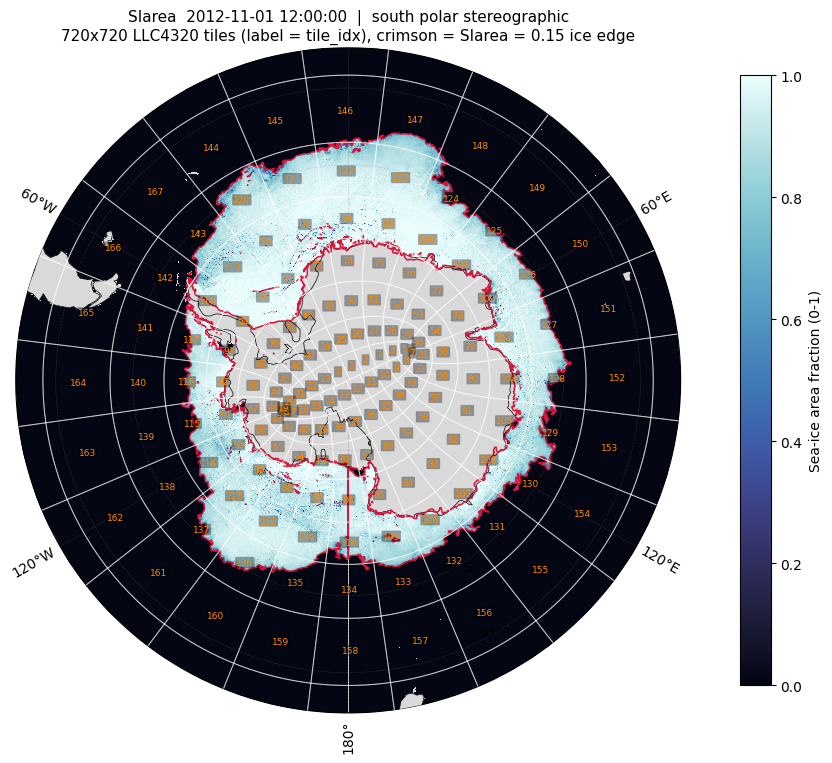

In [41]:
# Section 5b: SIarea over the Southern Ocean, with the tile grid.
fig = plt.figure(figsize=(11, 11))
ax = plt.subplot(1, 1, 1, projection=PROJ)
polar_axes(ax)
im = draw_sic(ax)

for t in SO_TILES:
    lons, lats = tile_outline_lonlat(t)
    ax.plot(lons, lats, transform=PC, color="w", lw=0.7,
            alpha=0.55, zorder=6)
    ic, jc = tile_centre_ij(t)
    if YC[jc, ic] <= SO_LAT_MAX - 1:      # skip labels off the edge
        ax.text(float(XC[jc, ic]), float(YC[jc, ic]), str(t),
                transform=PC, ha="center", va="center", fontsize=6.5,
                color="darkorange", zorder=7,
                bbox=dict(boxstyle="round,pad=0.12", fc="k",
                          ec="none", alpha=0.35))

cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.07)
cb.set_label("Sea-ice area fraction (0-1)")
ax.set_title(
    f"SIarea  {DATE}  |  south polar stereographic\n"
    f"720x720 LLC4320 tiles (label = tile_idx), "
    f"crimson = SIarea = {ICE_THRESHOLD} ice edge",
    fontsize=11)
plt.show()

## Section 6 — Rank every Southern Ocean tile by ice-edge quality

Per-tile statistics on the **full-resolution** 720 × 720 block:

| stat | meaning |
|---|---|
| `ocean` | fraction of the 518 400 cells that are ocean (not land / ice shelf) |
| `ice` | fraction of **ocean** cells with `SIarea >= 0.15` |
| `open` | `1 - ice` |
| `miz` | fraction of ocean cells in `0.15 <= SIarea < 0.80` — the marginal ice zone |
| `edge` | fraction of ocean cells on the 0.15 edge (`find_ice_edge`) |

The score is deliberately a plain, readable combination:

```
balance   = 4 * ice * open            # 1.0 at a 50/50 ice/open split
miz_term  = min(miz  / MIZ_REF,  1)   # rewards a wide marginal ice zone
edge_term = min(edge / EDGE_REF, 1)   # rewards a long, convoluted edge (~1-cell-wide line)
score     = ocean * (0.5*balance + 0.3*miz_term + 0.2*edge_term)
```

A tile **qualifies** only if it clears the hard floors
(`MIN_ICE`, `MIN_OPEN`, `MIN_OCEAN`) — that is the literal statement of
"contains grid locations that have ice *and* open ocean".  The weights
and floors are constants below; tune and re-run.

In [42]:
# Section 6a: per-tile statistics and score.
MIZ_REF   = 0.10     # miz fraction that saturates the MIZ term
EDGE_REF  = 0.004    # edge fraction that saturates the edge term
                     # (the edge is ~1 cell wide, so a tile crossed
                     #  twice by a convoluted edge is already ~0.004)
W_BALANCE, W_MIZ, W_EDGE = 0.5, 0.3, 0.2

MIN_ICE   = 0.10     # hard floors: a qualifying tile must have BOTH
MIN_OPEN  = 0.10     # ice and open water, on enough ocean to matter
MIN_OCEAN = 0.50


def tile_stats(tile_idx):
    """Ice-edge statistics + score for one 720x720 tile.

    Inputs : tile_idx (int).
    Outputs: dict of stats (see the Section 6 table) plus 'score',
             'qualifies', tile-centre lon/lat and rect indices.
    """
    jsl, isl = tile_rect_slices(tile_idx)
    sic  = SIC[jsl, isl]
    land = LAND[jsl, isl]
    ocean = ~land
    n_oc = int(ocean.sum())

    ic, jc = tile_centre_ij(tile_idx)
    rec = dict(tile=int(tile_idx), i=int(ic), j=int(jc),
               lon=float(XC[jc, ic]), lat=float(YC[jc, ic]),
               ocean=n_oc / ocean.size,
               ice=0.0, open=0.0, miz=0.0, edge=0.0,
               score=0.0, qualifies=False)
    if n_oc == 0:
        return rec

    v   = np.nan_to_num(sic, nan=0.0)
    ice = (v >= ICE_THRESHOLD) & ocean
    miz = ice & (v < MIZ_HIGH)
    edg = find_ice_edge(sic, land)

    rec["ice"]  = float(ice.sum()) / n_oc
    rec["open"] = 1.0 - rec["ice"]
    rec["miz"]  = float(miz.sum()) / n_oc
    rec["edge"] = float(edg.sum()) / n_oc

    balance   = 4.0 * rec["ice"] * rec["open"]
    miz_term  = min(rec["miz"] / MIZ_REF, 1.0)
    edge_term = min(rec["edge"] / EDGE_REF, 1.0)
    rec["score"] = rec["ocean"] * (W_BALANCE * balance
                                   + W_MIZ * miz_term
                                   + W_EDGE * edge_term)
    rec["qualifies"] = bool(rec["ice"] >= MIN_ICE
                            and rec["open"] >= MIN_OPEN
                            and rec["ocean"] >= MIN_OCEAN)
    return rec


STATS = [tile_stats(t) for t in SO_TILES]
RANKED = sorted(STATS, key=lambda r: -r["score"])
QUALIFIED = [r for r in RANKED if r["qualifies"]]
print(f"scored {len(STATS)} tiles; {len(QUALIFIED)} qualify "
      f"(ice >= {MIN_ICE}, open >= {MIN_OPEN}, "
      f"ocean >= {MIN_OCEAN})")

scored 192 tiles; 21 qualify (ice >= 0.1, open >= 0.1, ocean >= 0.5)


In [43]:
# Section 6b: leaderboard.
TOP_N = 12
hdr = (f"{'rank':>4s} {'tile':>5s} {'row':>4s} {'lon':>8s} {'lat':>7s} "
       f"{'ocean':>6s} {'ice':>6s} {'open':>6s} {'miz':>6s} "
       f"{'edge':>6s} {'score':>6s}  q")
print(hdr)
print("-" * len(hdr))
for k, r in enumerate(RANKED[:TOP_N], 1):
    print(f"{k:>4d} {r['tile']:>5d} {r['tile'] // N_TILE_I:>4d} "
          f"{r['lon']:>8.2f} {r['lat']:>7.2f} "
          f"{r['ocean']:>6.2f} {r['ice']:>6.2f} {r['open']:>6.2f} "
          f"{r['miz']:>6.3f} {r['edge']:>6.4f} {r['score']:>6.3f}  "
          f"{'Y' if r['qualifies'] else '-'}")
print("\nlon/lat are the TILE CENTRE (the pixel handed to "
      "`generate-tile --i/--j`).")

rank  tile  row      lon     lat  ocean    ice   open    miz   edge  score  q
-----------------------------------------------------------------------------
   1   129    5   104.51  -60.81   1.00   0.45   0.55  0.106 0.0114  0.995  Y
   2   124    5    29.51  -60.81   1.00   0.57   0.43  0.099 0.0093  0.987  Y
   3   114    4  -120.49  -67.25   1.00   0.71   0.29  0.118 0.0044  0.912  Y
   4   128    5    89.51  -60.81   1.00   0.52   0.48  0.068 0.0059  0.904  Y
   5   137    5  -135.49  -60.81   1.00   0.40   0.60  0.064 0.0062  0.872  Y
   6   130    5   119.51  -60.81   1.00   0.28   0.72  0.089 0.0101  0.870  Y
   7   115    4  -105.49  -67.25   1.00   0.49   0.51  0.054 0.0066  0.863  Y
   8   116    4   -90.49  -67.25   1.00   0.47   0.53  0.044 0.0050  0.829  Y
   9   143    5   -45.49  -60.81   1.00   0.32   0.68  0.064 0.0053  0.827  Y
  10   125    5    44.51  -60.81   1.00   0.49   0.51  0.041 0.0041  0.823  Y
  11   136    5  -150.49  -60.81   1.00   0.56   0.44  0.041 0.0

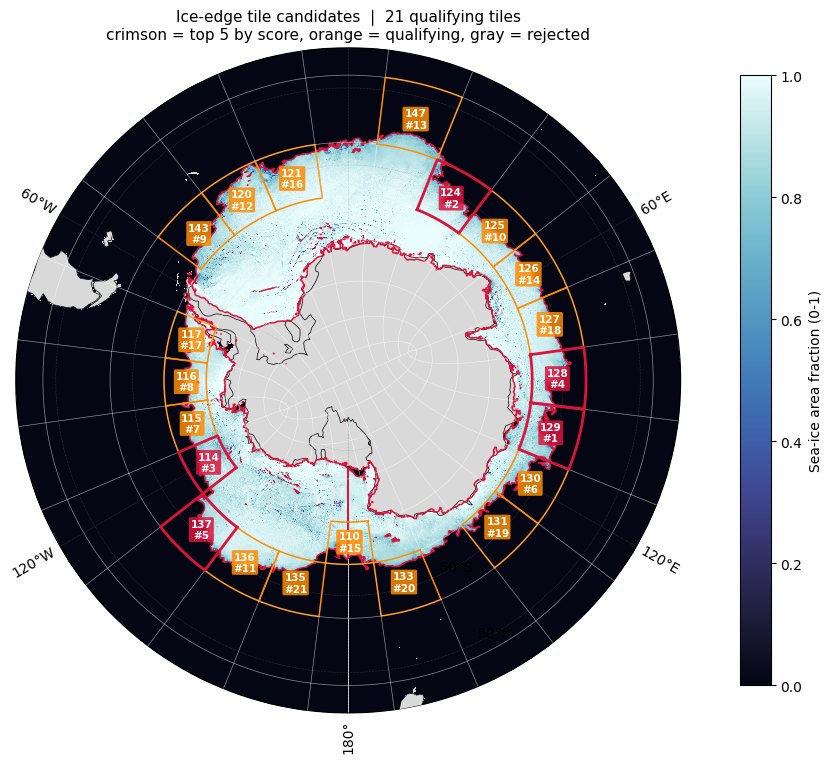

In [44]:
# Section 6c: where the qualifying tiles are.
fig = plt.figure(figsize=(11, 11))
ax = plt.subplot(1, 1, 1, projection=PROJ)
polar_axes(ax)
im = draw_sic(ax)

for r in STATS:
    lons, lats = tile_outline_lonlat(r["tile"])
    if not r["qualifies"]:
        ax.plot(lons, lats, transform=PC, color="w", lw=0.5,
                alpha=0.3, zorder=6)
        continue
    rank = RANKED.index(r) + 1
    top = rank <= 5
    ax.plot(lons, lats, transform=PC,
            color="crimson" if top else "darkorange",
            lw=2.0 if top else 1.1, zorder=7 if top else 6)
    ic, jc = tile_centre_ij(r["tile"])
    ax.text(float(XC[jc, ic]), float(YC[jc, ic]),
            f"{r['tile']}\n#{rank}", transform=PC, ha="center",
            va="center", fontsize=7.5, fontweight="bold",
            color="white", zorder=8,
            bbox=dict(boxstyle="round,pad=0.15",
                      fc="crimson" if top else "darkorange",
                      ec="none", alpha=0.85))

cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.07)
cb.set_label("Sea-ice area fraction (0-1)")
ax.set_title(
    f"Ice-edge tile candidates  |  {len(QUALIFIED)} qualifying tiles\n"
    "crimson = top 5 by score, orange = qualifying, gray = rejected",
    fontsize=11)
plt.show()

## Section 7 — Pick a tile

`TILE_IDX = None` takes the top-ranked tile.  **To override, set it to
any `tile_idx` from the leaderboard or the map above** — the rest of
the notebook follows whatever is set here, and the checks in Section 8
apply to it either way.

In [45]:
# Section 7a: THE choice.  Set TILE_IDX by hand to override.
TILE_IDX = 147          # e.g. TILE_IDX = 41

if TILE_IDX is None:
    assert QUALIFIED, (
        "no tile qualifies — relax MIN_ICE / MIN_OPEN / MIN_OCEAN, or "
        "widen SO_LAT_MAX, or pick a timestep with more ice")
    CHOSEN = QUALIFIED[0]
    print(f"auto-selected top-ranked tile {CHOSEN['tile']}")
else:
    CHOSEN = next(r for r in STATS if r["tile"] == TILE_IDX)
    rank = RANKED.index(CHOSEN) + 1
    print(f"manually selected tile {CHOSEN['tile']} "
          f"(rank {rank} of {len(STATS)}, "
          f"{'qualifies' if CHOSEN['qualifies'] else 'DOES NOT qualify'})")

for k, v in CHOSEN.items():
    print(f"  {k:10s} {v}")

manually selected tile 147 (rank 13 of 192, qualifies)
  tile       147
  i          2520
  j          4680
  lon        14.510416984558105
  lat        -52.87442398071289
  ocean      1.0
  ice        0.1984548611111111
  open       0.8015451388888889
  miz        0.0900559413580247
  edge       0.004266975308641975
  score      0.7883088824990354
  qualifies  True


In [46]:
# Section 7b: physical size of the chosen tile.
t = CHOSEN["tile"]
jsl, isl = tile_rect_slices(t)
jc, ic = (jsl.start + jsl.stop) // 2, (isl.start + isl.stop) // 2

area_km2 = np.nansum(RA[jsl, isl]) / 1e6
w_km = np.nansum(DXC[jc, isl]) / 1e3 if DXC is not None else np.nan
h_km = np.nansum(DYC[jsl, ic]) / 1e3 if DYC is not None else np.nan
cell_km = np.sqrt(np.nanmean(RA[jsl, isl])) / 1e3

print(f"TILE {t}   (tile_j_rect={t // N_TILE_I}, "
      f"tile_i_rect={t % N_TILE_I})")
print(f"  rect slices    j {jsl.start}:{jsl.stop}  "
      f"i {isl.start}:{isl.stop}   ({TILE_SIZE} x {TILE_SIZE} cells)")
print(f"  lon range      {np.nanmin(XC[jsl, isl]):8.2f} .. "
      f"{np.nanmax(XC[jsl, isl]):.2f} deg")
print(f"  lat range      {np.nanmin(YC[jsl, isl]):8.2f} .. "
      f"{np.nanmax(YC[jsl, isl]):.2f} deg")
print(f"  centre         lon {CHOSEN['lon']:.3f}, "
      f"lat {CHOSEN['lat']:.3f}")
print(f"  width x height {w_km:.0f} km x {h_km:.0f} km")
print(f"  area           {area_km2:,.0f} km^2")
print(f"  mean cell      {cell_km:.2f} km  "
      f"({1000 * cell_km:.0f} m)")
print(f"  depth          51 levels, full water column "
      f"(generate-tile output is (k=51, j=720, i=720))")

TILE 147   (tile_j_rect=6, tile_i_rect=3)
  rect slices    j 4320:5040  i 2160:2880   (720 x 720 cells)
  lon range          7.01 .. 21.99 deg
  lat range        -57.00 .. -48.40 deg
  centre         lon 14.510, lat -52.874
  width x height 1007 km x 957 km
  area           966,787 km^2
  mean cell      1.37 km  (1366 m)
  depth          51 levels, full water column (generate-tile output is (k=51, j=720, i=720))


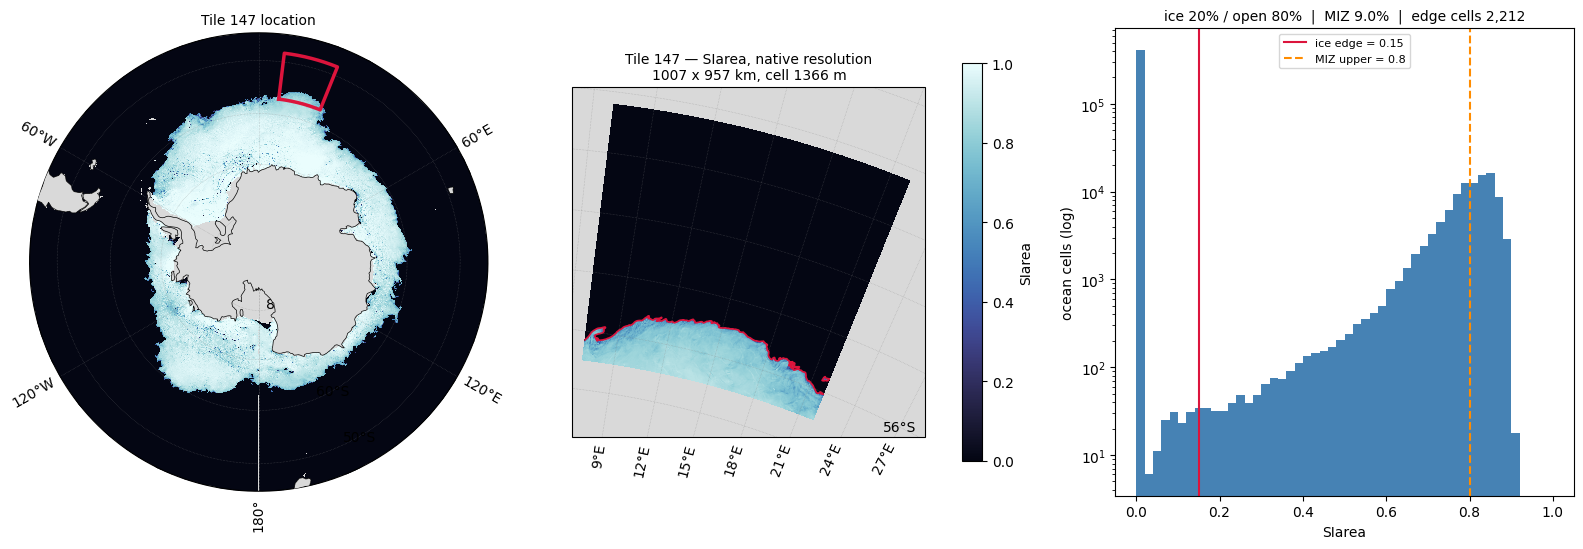

In [47]:
# Section 7c: the chosen tile in detail.
sic_t  = SIC[jsl, isl]
land_t = LAND[jsl, isl]
x_t, y_t = XC[jsl, isl], YC[jsl, isl]
edge_t = find_ice_edge(sic_t, land_t)

fig = plt.figure(figsize=(16, 5.6))

# (1) locator on the polar map
ax1 = plt.subplot(1, 3, 1, projection=PROJ)
polar_axes(ax1)
draw_sic(ax1, contour=False)
lons, lats = tile_outline_lonlat(t)
ax1.plot(lons, lats, transform=PC, color="crimson", lw=2.5, zorder=7)
ax1.set_title(f"Tile {t} location", fontsize=10)

# (2) the tile itself, full resolution.  Longitudes are taken from the
#     UNWRAPPED outline so a tile straddling +/-180 does not collapse
#     to a global extent; the mesh lon is unwrapped to match.
ax2 = plt.subplot(1, 3, 2, projection=PROJ)
x_plot = np.degrees(np.unwrap(np.radians(x_t.astype(float)), axis=1))
pad = 0.5
ax2.set_extent([float(lons.min()) - pad, float(lons.max()) + pad,
                float(lats.min()) - pad, float(lats.max()) + pad],
               crs=PC)
ax2.set_facecolor(LAND_COLOR)
im2 = ax2.pcolormesh(x_plot, y_t, np.where(land_t, np.nan, sic_t),
                     cmap=cmo.ice, vmin=0, vmax=1, shading="nearest",
                     transform=PC)
ax2.contour(x_plot, y_t, np.nan_to_num(sic_t, nan=0.0),
            levels=[ICE_THRESHOLD], colors="crimson", linewidths=1.2,
            transform=PC)
del x_plot
ax2.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
gl = ax2.gridlines(draw_labels=True, linewidth=0.4, color="0.5",
                   alpha=0.6, linestyle=":")
gl.top_labels = gl.right_labels = False
fig.colorbar(im2, ax=ax2, shrink=0.85, pad=0.08, label="SIarea")
ax2.set_title(f"Tile {t} — SIarea, native resolution\n"
              f"{w_km:.0f} x {h_km:.0f} km, cell {1000 * cell_km:.0f} m",
              fontsize=10)

# (3) distribution inside the tile
ax3 = plt.subplot(1, 3, 3)
vals = sic_t[~land_t]
vals = vals[np.isfinite(vals)]
ax3.hist(vals, bins=np.linspace(0, 1, 51), color="steelblue",
         log=True)
ax3.axvline(ICE_THRESHOLD, color="crimson", lw=1.5,
            label=f"ice edge = {ICE_THRESHOLD}")
ax3.axvline(MIZ_HIGH, color="darkorange", lw=1.5, ls="--",
            label=f"MIZ upper = {MIZ_HIGH}")
ax3.set_xlabel("SIarea")
ax3.set_ylabel("ocean cells (log)")
ax3.legend(fontsize=8)
ax3.set_title(
    f"ice {CHOSEN['ice']:.0%} / open {CHOSEN['open']:.0%}  |  "
    f"MIZ {CHOSEN['miz']:.1%}  |  edge cells {edge_t.sum():,}",
    fontsize=10)

plt.tight_layout()
plt.show()

## Section 8 — Resolve the tile and emit the `generate-tile` command

`rect_ij_to_tile()` is called **once**, here, on the chosen centre
pixel.  It rebuilds the `(13, 4320, 4320)` face lookup (a few seconds)
and returns the authoritative `TileInfo` — including which LLC **face**
the tile lives on and the face-local slices, which is what the viz tool
will ultimately read.

The checks below are the notebook's verification step: the rect-side
arithmetic used for scanning must agree with the library, and the
chosen tile must actually straddle the ice edge.

In [48]:
# Section 8a: authoritative resolution via the library.
from dbof.tiles.tile_mapping import rect_ij_to_tile

i_c, j_c = tile_centre_ij(t)
info = rect_ij_to_tile(i_c, j_c)

print(f"TileInfo for rect pixel (i={i_c}, j={j_c}):")
for f in ("tile_idx", "tile_j_rect", "tile_i_rect", "rect_j_slice",
          "rect_i_slice", "face_idx", "j_face_slice", "i_face_slice"):
    print(f"  {f:14s} {getattr(info, f)}")

TileInfo for rect pixel (i=2520, j=4680):
  tile_idx       147
  tile_j_rect    6
  tile_i_rect    3
  rect_j_slice   slice(4320, 5040, None)
  rect_i_slice   slice(2160, 2880, None)
  face_idx       1
  j_face_slice   slice(0, 720, None)
  i_face_slice   slice(2160, 2880, None)


In [49]:
# Section 8b: verification.
checks = []

def check(name, ok, detail=""):
    checks.append((name, bool(ok), detail))

check("tile_idx round-trips", info.tile_idx == t,
      f"{info.tile_idx} vs {t}")
check("rect j slice matches scan", info.rect_j_slice == jsl,
      f"{info.rect_j_slice} vs {jsl}")
check("rect i slice matches scan", info.rect_i_slice == isl,
      f"{info.rect_i_slice} vs {isl}")
check("tile is 720x720", sic_t.shape == (TILE_SIZE, TILE_SIZE),
      str(sic_t.shape))
check("tile lives on one face", 0 <= info.face_idx < 13,
      f"face {info.face_idx}")
check("tile has ICE cells",
      (np.nan_to_num(sic_t, nan=0.0) >= ICE_THRESHOLD).sum() > 0,
      f"{int((np.nan_to_num(sic_t, nan=0.0) >= ICE_THRESHOLD).sum()):,}")
check("tile has OPEN-OCEAN cells",
      ((np.nan_to_num(sic_t, nan=1.0) < ICE_THRESHOLD)
       & ~land_t).sum() > 0,
      f"{int(((np.nan_to_num(sic_t, nan=1.0) < ICE_THRESHOLD) & ~land_t).sum()):,}")
check("tile contains the ice edge", edge_t.sum() > 0,
      f"{int(edge_t.sum()):,} edge cells")
check("tile is mostly ocean", CHOSEN["ocean"] >= MIN_OCEAN,
      f"{CHOSEN['ocean']:.2f}")
check("SIarea within [0, 1]",
      np.nanmin(sic_t) >= -1e-6 and np.nanmax(sic_t) <= 1 + 1e-6,
      f"[{np.nanmin(sic_t):.3f}, {np.nanmax(sic_t):.3f}]")

for name, ok, detail in checks:
    print(f"[{'PASS' if ok else 'FAIL'}] {name:32s} {detail}")
assert all(ok for _, ok, _ in checks), "one or more checks failed"
print("\nAll checks passed.")

[PASS] tile_idx round-trips             147 vs 147
[PASS] rect j slice matches scan        slice(4320, 5040, None) vs slice(4320, 5040, None)
[PASS] rect i slice matches scan        slice(2160, 2880, None) vs slice(2160, 2880, None)
[PASS] tile is 720x720                  (720, 720)
[PASS] tile lives on one face           face 1
[PASS] tile has ICE cells               102,879
[PASS] tile has OPEN-OCEAN cells        415,521
[PASS] tile contains the ice edge       2,212 edge cells
[PASS] tile is mostly ocean             1.00
[PASS] SIarea within [0, 1]             [0.000, 0.907]

All checks passed.


In [50]:
# Section 8c: the command to build this tile.
print(f"# Chosen tile: {t}  (face {info.face_idx}, "
      f"centre lon {CHOSEN['lon']:.3f}, lat {CHOSEN['lat']:.3f})")
print(f"# ice {CHOSEN['ice']:.0%} / open {CHOSEN['open']:.0%}, "
      f"MIZ {CHOSEN['miz']:.1%}, "
      f"{w_km:.0f} x {h_km:.0f} km, cell ~{1000 * cell_km:.0f} m\n")

for prop in ("SIarea", "density", "N2", "Ri", "relative_vorticity"):
    print(f"generate-tile --i {i_c} --j {j_c} \\\n"
          f"    --timestamp '{DATE}' --property {prop} --qa-plot\n")

print("# equivalent geographic form (resolved back to the same tile):")
print(f"generate-tile --lon {CHOSEN['lon']:.4f} "
      f"--lat {CHOSEN['lat']:.4f} \\\n"
      f"    --timestamp '{DATE}' --property density")
print("\n# available properties:")
from dbof.tiles import tile_utils
print("  " + ", ".join(sorted(tile_utils.TILE_PROPERTIES)))

# Chosen tile: 147  (face 1, centre lon 14.510, lat -52.874)
# ice 20% / open 80%, MIZ 9.0%, 1007 x 957 km, cell ~1366 m

generate-tile --i 2520 --j 4680 \
    --timestamp '2012-11-01 12:00:00' --property SIarea --qa-plot

generate-tile --i 2520 --j 4680 \
    --timestamp '2012-11-01 12:00:00' --property density --qa-plot

generate-tile --i 2520 --j 4680 \
    --timestamp '2012-11-01 12:00:00' --property N2 --qa-plot

generate-tile --i 2520 --j 4680 \
    --timestamp '2012-11-01 12:00:00' --property Ri --qa-plot

generate-tile --i 2520 --j 4680 \
    --timestamp '2012-11-01 12:00:00' --property relative_vorticity --qa-plot

# equivalent geographic form (resolved back to the same tile):
generate-tile --lon 14.5104 --lat -52.8744 \
    --timestamp '2012-11-01 12:00:00' --property density

# available properties:
  Bu, Eta, Fr, KE, N2, R_ib, Ri, Ro, SIarea, Salt, Theta, U, V, W, Wstar, buoyancy, coriolis_f, density, divergence, ekman_pumping, ertel_pv, ertel_pv_tilt, ertel_pv_vertical, fr

## Section 9 — From this tile to a CHUNK transfer

**There is no "chunk number."**  `transfer_llc4320.py` in `chunks` mode is
addressed *geographically*, not by index: `transfer.location` takes
`lat`, `lon`, and a `chunk_name` directory label.
`dbof.transfer.chunk_selection.resolve_chunk` finds the native cell
nearest that lat/lon and floors its **face-local** `(j, i)` to the
enclosing 720 × 720 block.

### The tile *is* the chunk

The two resolvers are the same operation reached from opposite sides:

| | tiles (`dbof.tiles.tile_mapping`) | transfer (`dbof.transfer.chunk_selection`) |
|---|---|---|
| entry point | `rect_ij_to_tile(i_rect, j_rect)` | `resolve_chunk(ds, lat, lon)` |
| searches | the **stitched rect** grid | the **native** `(face, j, i)` store |
| returns | `face_idx`, `j_face_slice`, `i_face_slice` | `face_idx`, `j0`, `i0` |
| block | 720 × 720, floored to the grid | 720 × 720, floored to the grid |

Same 13 faces, same face-local 720 lattice → **the chunk resolved from
this tile's centre lon/lat is bit-for-bit the same native block as the
tile.**  `j_face_slice.start == j0` and `i_face_slice.start == i0`.

The one way the identity could break is the nearest-cell search landing
in a *neighbouring* block — the two searches use slightly different
distance metrics (`resolve_chunk` weights `dlon` by `cos(lat)`,
`latlon_to_rect_ij` does not), so they can disagree by a cell or two
right on a boundary.  Feeding the **tile centre** leaves 360 cells of
margin in every direction, so it cannot happen here.  That is why
Section 9a uses `CHOSEN['lon'] / CHOSEN['lat']` (the centre) and not a
corner or an ice-edge point.

### ⚠ The transfer date is not the selection date

This tile was chosen from the `SIarea` field at the timestep in `DATE`
above.  If you transfer a **different** date, the ice edge will have
moved — the Antarctic edge migrates hundreds of km between austral
spring and summer, so a tile that straddles the edge in early November
can be entirely ice-free by mid-December.

Before committing to a 24-hour transfer, re-run Sections 1–7 with
`DATE` / `DATE_PREFIX` set to the transfer date and confirm tile 147
still qualifies.  Section 9a prints that check as a reminder.

In [ ]:
# Section 9a: the CHUNK transfer config block for the chosen tile.
from datetime import datetime, timedelta

from dbof.llc4320_ingestion.date_iterations import (
    DATE_FMT, mit_date_to_iteration, date_to_run_id,
)

# ---- the transfer request -------------------------------------------
TRANSFER_START = "2011-12-12 11:00:00"   # first hourly timestep
N_HOURS        = 24                      # consecutive hourly timesteps
CHUNK_NAME     = f"so_ice_edge_tile{t:03d}"

_t0 = datetime.strptime(TRANSFER_START, DATE_FMT)
TRANSFER_DATES = [(_t0 + timedelta(hours=h)).strftime(DATE_FMT)
                  for h in range(N_HOURS)]

print(f"chunk_name : {CHUNK_NAME}")
print(f"location   : lat {CHOSEN['lat']:.6f}, lon {CHOSEN['lon']:.6f}  "
      f"(centre of tile {t})")
print(f"native block: face {info.face_idx}, "
      f"j {info.j_face_slice.start}:{info.j_face_slice.stop}, "
      f"i {info.i_face_slice.start}:{info.i_face_slice.stop}")
print(f"dates      : {TRANSFER_DATES[0]} .. {TRANSFER_DATES[-1]}  "
      f"({N_HOURS} hourly steps)")
print(f"MIT iters  : {mit_date_to_iteration(TRANSFER_DATES[0])} .. "
      f"{mit_date_to_iteration(TRANSFER_DATES[-1])} "
      f"(step 144 = 1 h)")
print(f"output     : dbof/LLC4320_RAW/CHUNKS/{CHUNK_NAME}/"
      "{grid.zarr | <date>/}")
print()
print(f"!! tile {t} was selected on {DATE}; you are transferring "
      f"{TRANSFER_START}.")
print("!! re-run Sections 1-7 with DATE / DATE_PREFIX set to the "
      "transfer date")
print(f"!!   DATE = '{TRANSFER_DATES[0]}' ; "
      f"DATE_PREFIX = '{date_to_run_id(TRANSFER_DATES[0])}'")
print("!! and confirm tile {} still straddles the ice edge before "
      "transferring.".format(t))

In [ ]:
# Section 9b: paste-ready YAML for the chunks-mode transfer config.
#   configs/transfer/run_chunks_so_ice_edge.yaml
#   (copy configs/transfer/run_chunks_monterey_bay.yaml and replace the
#    `data.date_iterations` and `transfer.location` blocks with these)
yaml_dates = "\n".join(f"    - '{d}'" for d in TRANSFER_DATES)

print(f"""\
# --- data ------------------------------------------------------------
data:
  MIT_data_path: "/orcd/data/abodner/003/LLC4320/LLC4320"
  date_iterations:
{yaml_dates}

# --- transfer --------------------------------------------------------
transfer:
  mode: "chunks"

  # Tile {t} of the LLC4320 rect grid (tile_j_rect={t // N_TILE_I}, \
tile_i_rect={t % N_TILE_I}).
  # Selected on the Southern Ocean sea-ice edge in
  # notebooks/notebooks_viz/tile_selection_southernocean_icearea.ipynb
  # This lat/lon is the TILE CENTRE; resolve_chunk floors it to the
  # same native 720x720 block: face {info.face_idx}, \
j {info.j_face_slice.start}, i {info.i_face_slice.start}.
  location:
    lat: {CHOSEN['lat']:.6f}
    lon: {CHOSEN['lon']:.6f}
    chunk_name: "{CHUNK_NAME}"

  tile_j: 720
  tile_i: 720
""")

print("# run it with:")
print("#   transfer-timestep --config "
      "configs/transfer/run_chunks_so_ice_edge.yaml --init-store")
print("# (run from the MIT machines — MIT_data_path is a local path)")

In [ ]:
# Section 9c: what the transferred store must report back.
#
# dbof.transfer.chunk_selection.chunk_provenance writes these attrs onto
# every store it creates.  They are the post-transfer proof that the
# chunk and this tile are the same native block.
expected = {
    "chunk_name":     CHUNK_NAME,
    "requested_lat":  round(float(CHOSEN["lat"]), 6),
    "requested_lon":  round(float(CHOSEN["lon"]), 6),
    "resolved_face":  int(info.face_idx),
    "j_start":        int(info.j_face_slice.start),
    "i_start":        int(info.i_face_slice.start),
    "tile_size":      int(TILE_SIZE),
}
print("expected attrs on "
      f"dbof/LLC4320_RAW/CHUNKS/{CHUNK_NAME}/grid.zarr:")
for k, v in expected.items():
    print(f"  {k:15s} {v}")

print("\nafter the transfer, verify with:")
print(f"""
import zarr, dbof.io.filesystems as filesystems
fs, _ = filesystems.create_s3_filesystems(S3_ENDPOINT)
g = zarr.open_group(store=zarr.storage.FsspecStore(
    path="dbof/LLC4320_RAW/CHUNKS/{CHUNK_NAME}/grid.zarr", fs=fs),
    mode="r", use_consolidated=False)
for k, v in {expected!r}.items():
    got = g.attrs.get(k)
    print(f"  {{k:15s}} expected {{v}}  got {{got}}  "
          f"{{'OK' if got == v else 'MISMATCH'}}")
""")

## Decision record

| | |
|---|---|
| Chosen `tile_idx` | **147** (tile_j_rect 6, tile_i_rect 3) |
| Rect centre pixel | `--i 2520 --j 4680` |
| Centre lon / lat | 14.510 E, -52.874 N |
| LLC face / native block | face 1, `j 0:720`, `i 2160:2880` |
| Size | 1007 x 957 km, 966 787 km², ~1.37 km cells, 51 levels |
| Why this one | Atlantic-sector ice edge; 20% ice / 80% open ocean, MIZ 9%, 2212 edge cells, zero land |
| CHUNK transfer | `transfer.location: {lat: -52.874424, lon: 14.510417, chunk_name: so_ice_edge_tile147}` (Section 9) |

**Cross-references** — field validation of `SIarea`:
`notebooks/notebooks_field_validation/surface_fields/icearea.ipynb`.
Tile machinery: `docs/Tiles.md`, `dbof.tiles.tile_mapping`,
`dbof.tiles.tile_utils`, `generate-tile`.
Transfer machinery: `dbof.transfer.chunk_selection`,
`dbof.cli.transfer_llc4320`, `configs/transfer/run_chunks_monterey_bay.yaml`.